In [1]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_160226.csv'

In [3]:
# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

#### fixing csv and georreferencing data

In [4]:
df = pd.read_csv(ground_data_path, sep=";")
df

,HORA,TA1,TG1,TA2,TG2,ANEMOMETRO,CONDICION CIELO
0,16:28,"26,3","29,6","26,2","29,6",0,RESOLANA SUAVE
1,16:30,"26,3","32,8","26,2","31,1",0,SOL
2,16:32,"25,8","29,5","25,7","28,4",0,RESOLANA SUAVE
3,16:36,26,"28,9","25,8","27,5",0,RESOLANA SUAVE
4,16:39,"26,3","29,8",26,"28,3",0,RESOLANA FUERTE
5,16:42,"27,4","34,8","27,9","31,6","0,7",RESOLANA MUY FUERTE
6,16:43,"27,4","37,4","27,9","32,4","3,9",SOL
7,16:44,"29,2","43,8","29,5","37,3",0,SOL
8,16:50,"27,1","31,2","26,9","28,9",0,RESOLANA SUAVE
9,16:53,"26,4","30,9","25,9","28,3",0,RESOLANA SUAVE


In [5]:
# convert to numeric

cols = ["TG1", "TG2", "TA1", "TA2", "ANEMOMETRO"]


df[cols] = (
    df[cols]
    .astype(str)
    .apply(lambda x: x.str.replace(",", ".", regex=False))
    .apply(pd.to_numeric, errors="coerce")
)

# TG difference
df["dTG"] = df["TG1"] - df["TG2"]


In [6]:
df

,HORA,TA1,TG1,TA2,TG2,ANEMOMETRO,CONDICION CIELO,dTG
0,16:28,26.3,29.6,26.2,29.6,0.0,RESOLANA SUAVE,0.0
1,16:30,26.3,32.8,26.2,31.1,0.0,SOL,1.7
2,16:32,25.8,29.5,25.7,28.4,0.0,RESOLANA SUAVE,1.1
3,16:36,26.0,28.9,25.8,27.5,0.0,RESOLANA SUAVE,1.4
4,16:39,26.3,29.8,26.0,28.3,0.0,RESOLANA FUERTE,1.5
5,16:42,27.4,34.8,27.9,31.6,0.7,RESOLANA MUY FUERTE,3.2
6,16:43,27.4,37.4,27.9,32.4,3.9,SOL,5.0
7,16:44,29.2,43.8,29.5,37.3,0.0,SOL,6.5
8,16:50,27.1,31.2,26.9,28.9,0.0,RESOLANA SUAVE,2.3
9,16:53,26.4,30.9,25.9,28.3,0.0,RESOLANA SUAVE,2.6


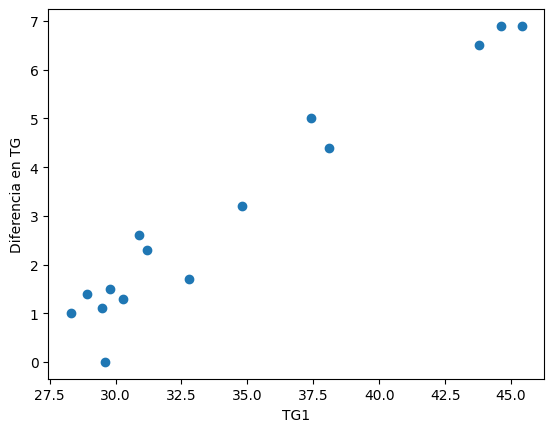

In [7]:
# Scatter: TG1 vs dTG
plt.scatter(df["TG1"], df["dTG"])
plt.xlabel("TG1")
plt.ylabel("Diferencia en TG")
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression

X = df[["TG1"]]   # predictor must be 2D
y = df["TG2"]

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Coefficients
a = model.coef_[0]
b = model.intercept_

print(f"TG2 = {a:.3f} * TG1 + {b:.3f}")

# Apply correction: "pass" TG1 to TG2-equivalent
df["TG1_corr"] = a * df["TG1"] + b
df["dTG_CORR"] = df["TG1_corr"] - df["TG2"]

reduction_rmse = (
    1 - np.sqrt((df["dTG_CORR"]**2).mean()) /
        np.sqrt((df["dTG"]**2).mean())
) * 100

print(f"RMSE reduction: {reduction_rmse:.1f} %")


TG2 = 0.628 * TG1 + 9.732
RMSE reduction: 86.1 %


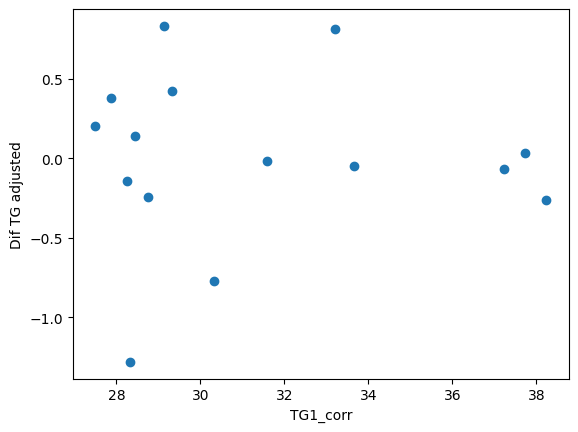

In [10]:
# Scatter: TG1 vs dTG
plt.scatter(df["TG1_corr"], df["dTG_CORR"])
plt.xlabel("TG1_corr")
plt.ylabel("Dif TG adjusted")
plt.show()

In [11]:
import numpy as np

metrics = pd.DataFrame({
    "metric": ["mean", "std", "RMSE", "MAE"],
    "dTG_raw": [
        df["dTG"].mean(),
        df["dTG"].std(),
        np.sqrt((df["dTG"]**2).mean()),
        df["dTG"].abs().mean()
    ],
    "dTG_corr": [
        df["dTG_CORR"].mean(),
        df["dTG_CORR"].std(),
        np.sqrt((df["dTG_CORR"]**2).mean()),
        df["dTG_CORR"].abs().mean()
    ]
})

print(metrics)


  metric   dTG_raw      dTG_corr
0   mean  3.053333 -2.368476e-16
1    std  2.318826  5.438599e-01
2   RMSE  3.786995  5.254186e-01
3    MAE  3.053333  3.775881e-01


C:\Users\guada\AppData\Local\Temp\ipykernel_9004\3944679771.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


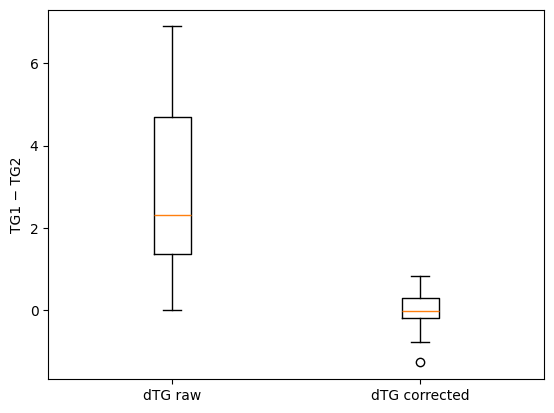

In [13]:
plt.boxplot(
    [df["dTG"].dropna(), df["dTG_CORR"].dropna()],
    labels=["dTG raw", "dTG corrected"]
)
plt.ylabel("TG1 − TG2")
plt.show()


MRT

In [77]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Avoid zero wind (ISO recommendation)
v = df["ANEMOMETRO"].clip(lower=0.1)
v = v / 3.6


# MRT from TG1
df["MRT1"] = (
    (
        (df["TG1_corr"] + 273.15)**4
        + (1.1e8 * v**0.6 / (eps * D1**0.4)) * (df["TG1_corr"] - df["TA1"])
    )**0.25
    - 273.15
)

# MRT from TG2
df["MRT2"] = (
    (
        (df["TG2"] + 273.15)**4
        + (1.1e8 * v**0.6 / (eps * D2**0.4)) * (df["TG2"] - df["TA2"])
    )**0.25
    - 273.15
)

# MRT difference
df["dMRT"] = df["MRT1"] - df["MRT2"]


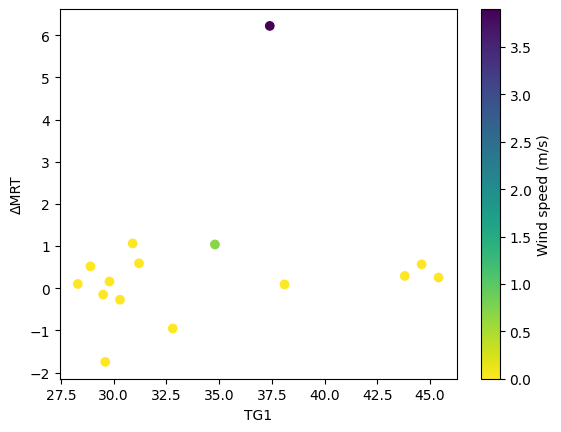

In [91]:
plt.scatter(
    df["TG1"],
    df["dMRT"],
    c=df["ANEMOMETRO"],
    cmap="viridis_r"
)

plt.xlabel("TG1")
plt.ylabel("ΔMRT")

cbar = plt.colorbar()
cbar.set_label("Wind speed (m/s)")

plt.show()


not working so good. Better take points with no wind